In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\Jashanjot\Downloads\fraudTrain.csv.zip")

# Look at the first few rows and column types
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [24]:
import pandas as pd
import numpy as np

# 1. To convert dates
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# 2. Feature Engineering
df['hour'] = df['trans_date_trans_time'].dt.hour
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df['distance'] = np.sqrt((df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2)

# 3. Drop columns that won't help the model
cols_to_drop = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num', 'trans_date_trans_time', 'dob', 'unix_time']
df_clean = df.drop(columns=cols_to_drop)

print(df_clean.head())

                             merchant       category     amt gender  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97      F   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23      F   
2                fraud_Lind-Buckridge  entertainment  220.11      M   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00      M   
4                 fraud_Keeling-Crist       misc_pos   41.96      M   

             city state    zip      lat      long  city_pop  \
0  Moravian Falls    NC  28654  36.0788  -81.1781      3495   
1          Orient    WA  99160  48.8878 -118.2105       149   
2      Malad City    ID  83252  42.1808 -112.2620      4154   
3         Boulder    MT  59632  46.2306 -112.1138      1939   
4        Doe Hill    VA  24433  38.4207  -79.4629        99   

                                 job  merch_lat  merch_long  is_fraud  hour  \
0          Psychologist, counselling  36.011293  -82.048315         0     0   
1  Special educational needs teacher

In [25]:
# Check the distribution of fraud vs legitimate
print("Target Variable Balance:")
print(df_clean['is_fraud'].value_counts(normalize=True))

Target Variable Balance:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We drop 'is_fraud' from X because that's what we want to predict
X = df_clean.drop('is_fraud', axis=1) 
y = df_clean['is_fraud']

# 2. Split the data into Training (80%) and Testing (20%)
# 'stratify=y' is vital because fraud is so rare; it ensures both sets get fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Data successfully split!")
print(f"Training samples: {X_train.shape[0]}")

Data successfully split!
Training samples: 1037340


In [27]:
from sklearn.utils import resample

# 1. Combine X_train and y_train only
train_data = pd.concat([X_train, y_train], axis=1)

# 2. Separate the classes within the training set
not_fraud = train_data[train_data.is_fraud == 0]
fraud = train_data[train_data.is_fraud == 1]

# 3. Downsample majority
not_fraud_downsampled = resample(not_fraud, replace=False, n_samples=len(fraud), random_state=42)

# 4. Create the final balanced training set
balanced_train = pd.concat([not_fraud_downsampled, fraud])
X_train_balanced = balanced_train.drop('is_fraud', axis=1)
y_train_balanced = balanced_train['is_fraud']

In [28]:
# 1. Define Features (X) and Target (y)
# We must drop ALL non-numerical columns before fitting the model
cols_to_exclude = [
    'is_fraud', 'merchant', 'category', 'first', 'last', 
    'gender', 'street', 'city', 'state', 'job', 'trans_num'
]

# We only keep the numbers (amt, city_pop, hour, age, distance, etc.)
X = df_clean.drop(columns=[c for c in cols_to_exclude if c in df_clean.columns])
y = df_clean['is_fraud']

# 2. Split the data again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Columns being sent to the model:", X.columns.tolist())

Columns being sent to the model: ['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'hour', 'age', 'distance']


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

# Initialize the model
# n_estimators=100 means we use 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train on your downsampled or balanced data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.85      0.54      0.66      1501

    accuracy                           1.00    259335
   macro avg       0.92      0.77      0.83    259335
weighted avg       1.00      1.00      1.00    259335



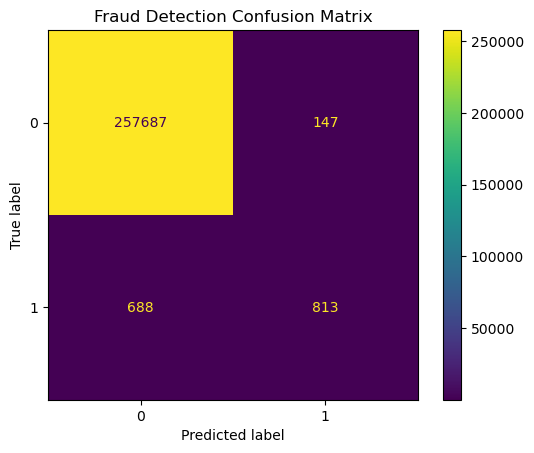

In [30]:
# Print the detailed report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Fraud Detection Confusion Matrix")
plt.show()

In [ ]:
# Save the model to a file
joblib.dump(rf_model, 'fraud_model.pkl')


model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!


In [ ]:
import joblib

# 1. Save the newly trained model
joblib.dump(rf_model, 'fraud_model.pkl')

# 2. Save the files
joblib.dump(X_train.columns.tolist(), 'model_columns.pkl')

print("Assets updated! Model and Columns are synced.")

Assets updated! Model and Columns are synced.
